In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/thedevastator/rsicd-image-caption-dataset/valid.csv
/kaggle/input/datasets/thedevastator/rsicd-image-caption-dataset/train.csv
/kaggle/input/datasets/thedevastator/rsicd-image-caption-dataset/test.csv


In [2]:
!pip install transformers datasets accelerate timm -q

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import json
import os

from transformers import BlipProcessor, BlipForConditionalGeneration
from torch.optim import AdamW
from tqdm import tqdm

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedevastator/rsicd-image-caption-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/thedevastator/rsicd-image-caption-dataset


In [5]:
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image
from io import BytesIO
import ast

class RSICD_CSV_Dataset(Dataset):
    def __init__(self, csv_file, processor):
        self.df = pd.read_csv(csv_file)
        self.processor = processor
        
        self.samples = []

        for _, row in self.df.iterrows():
            # Convert string list → actual list
            captions = ast.literal_eval(row["captions"])
            
            image_bytes = eval(row["image"])["bytes"]
            
            for caption in captions:
                self.samples.append((image_bytes, caption))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_bytes, caption = self.samples[idx]

        image = Image.open(BytesIO(image_bytes)).convert("RGB")

        caption = caption.lower().strip()

        encoding = self.processor(
            images=image,
            text=caption,
            padding="max_length",
            truncation=True,
            max_length=30,
            return_tensors="pt"
        )

        encoding = {k: v.squeeze(0) for k, v in encoding.items()}
        encoding["labels"] = encoding["input_ids"]

        return encoding

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"


In [7]:
device

'cuda'

In [8]:
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

model.to(device)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-0

In [9]:
train_dataset = RSICD_CSV_Dataset(
    "/kaggle/input/datasets/thedevastator/rsicd-image-caption-dataset/test.csv",
    processor
)

val_dataset = RSICD_CSV_Dataset(
    "/kaggle/input/datasets/thedevastator/rsicd-image-caption-dataset/valid.csv",
    processor
)

In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8
)
LR = 5e-5   

optimizer = AdamW(model.parameters(), lr=LR)

In [11]:
BATCH_SIZE = 8   # P100 safe
EPOCHS = 5



for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for batch in tqdm(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            val_loss += outputs.loss.item()

    print(f"""
    Epoch {epoch+1}
    Train Loss: {train_loss/len(train_loader)}
    Val Loss: {val_loss/len(val_loader)}
    """)

100%|██████████| 137/137 [02:44<00:00,  1.20s/it]



    Epoch 1
    Train Loss: 2.5763165785448394
    Val Loss: 2.54008190388227
    


100%|██████████| 137/137 [02:47<00:00,  1.22s/it]



    Epoch 2
    Train Loss: 1.583885022323497
    Val Loss: 2.5392981419598097
    


100%|██████████| 137/137 [02:47<00:00,  1.22s/it]



    Epoch 3
    Train Loss: 1.185787385397584
    Val Loss: 2.643583758904116
    


100%|██████████| 137/137 [02:47<00:00,  1.22s/it]



    Epoch 4
    Train Loss: 0.8541695353758596
    Val Loss: 2.8961916504985226
    


100%|██████████| 137/137 [02:47<00:00,  1.22s/it]



    Epoch 5
    Train Loss: 0.5770603457506556
    Val Loss: 3.0508898992608064
    


In [12]:
SAVE_PATH = "/kaggle/working/blip_rsicd_finetuned"

model.save_pretrained(SAVE_PATH)
processor.save_pretrained(SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['/kaggle/working/blip_rsicd_finetuned/processor_config.json']

Total samples: 1093
🖼️ Generated Caption: there ' s a lot of parking spaces in the airport. many white planes were parked at the airport. many white planes were parked at the


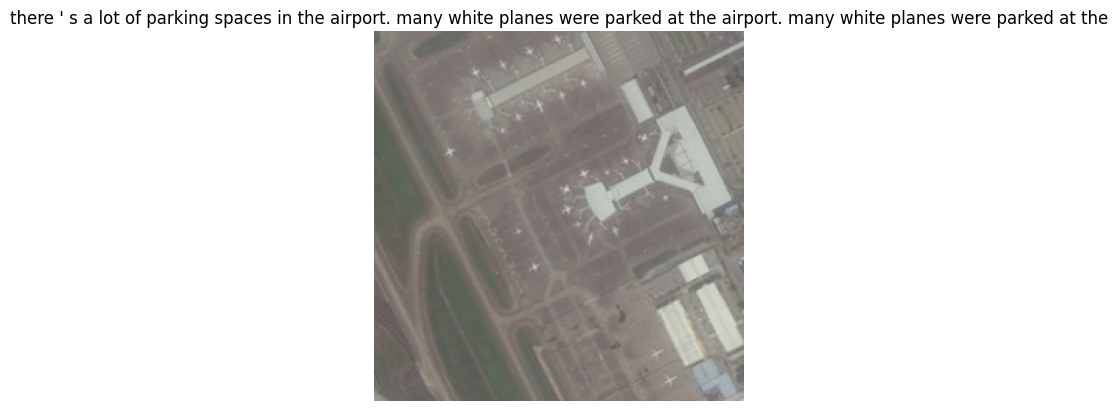

In [13]:
df = pd.read_csv("/kaggle/input/datasets/thedevastator/rsicd-image-caption-dataset/test.csv")

print("Total samples:", len(df))


def load_image_from_row(row):
    img_data = row["image"]

    # Case 1: string dict (most common)
    if isinstance(img_data, str):
        img_dict = ast.literal_eval(img_data)   # ✅ FIX
        image_bytes = img_dict["bytes"]

    # Case 2: already dict
    elif isinstance(img_data, dict):
        image_bytes = img_data["bytes"]

    else:
        raise ValueError("Unknown image format")

    image = Image.open(BytesIO(image_bytes)).convert("RGB")
    return image


row = df.iloc[0]

image = load_image_from_row(row)

inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    output = model.generate(
        **inputs,
        max_length=30,
        num_beams=5,
        early_stopping=True
    )

caption = processor.decode(output[0], skip_special_tokens=True)

print("🖼️ Generated Caption:", caption)


import matplotlib.pyplot as plt

plt.imshow(image)
plt.axis("off")
plt.title(caption)
plt.show()